# Avaliação — APIs de energia renovável e aprendizado de máquina

Consulte duas APIs públicas, organize os dados e resolva **duas tarefas**: classificar a fonte de empreendimentos da ANEEL e estimar a radiação solar em Petrolina (PE). Em **cada tarefa**, treine e compare **três algoritmos diferentes**. Este notebook fornece a consulta às APIs e os arquivos de dados; **você implementará a análise e os modelos**.

**Entrega:** um único link para um repositório público no GitHub com notebook executável, arquivos de dados, README e resultados. As instruções completas estão ao final e no enunciado separado.

> **Resolução — Renan de Castro Albuquerque (FIAP · Ciência da Computação)**
>
> Este notebook mantém a consulta às APIs fornecida pelo professor e acrescenta a análise exploratória, os **três classificadores** (Regressão Logística, kNN e Random Forest) e os **três regressores** (Regressão Linear, Árvore de Decisão e Random Forest), com métricas, gráficos e interpretação.
>
> **Reprodutibilidade:** os CSVs versionados no repositório são os que geraram os resultados abaixo. Com `ATUALIZAR_DADOS = False` (padrão) o notebook reutiliza esses arquivos; com `True`, consulta as APIs novamente e sobrescreve os CSVs. Como o cadastro da ANEEL muda com o tempo, uma nova consulta pode alterar ligeiramente os números.

## O que é recebido da API?

Uma requisição HTTP `GET` pede dados a uma URL. Os parâmetros identificam o recurso, o período e as variáveis. A resposta é **JSON**: um objeto com chaves e valores. Nas duas consultas desta avaliação, o acesso público **não exige login, token ou chave de API**. Se outra API exigir credenciais, não as publique no repositório.

Este código usa somente `json`, `urllib` e `csv`, bibliotecas que vêm com Python. `csv` serve apenas para exportar os dados recebidos; os imports para análise, tabelas, gráficos e ML são parte da sua implementação.

In [1]:
import json
import urllib.parse
import urllib.request
import csv
from pathlib import Path

# Imports adicionados para análise, gráficos e aprendizado de máquina
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report,
                             mean_absolute_error, mean_squared_error, r2_score)

SEMENTE = 42                 # semente fixa para divisões e modelos
ATUALIZAR_DADOS = False      # True = consulta as APIs de novo e sobrescreve os CSVs
PASTA_FIG = Path("figuras"); PASTA_FIG.mkdir(exist_ok=True)
sns.set_theme(style="whitegrid")
pd.set_option("display.precision", 3)

A função a seguir monta a URL, abre a conexão, verifica o status HTTP e converte o JSON. Se houver falha na rede ou na API, exibe uma mensagem de erro.

In [2]:
def consultar_api(endereco, parametros):
    url = endereco + "?" + urllib.parse.urlencode(parametros)
    try:
        with urllib.request.urlopen(url, timeout=30) as resposta:
            return json.load(resposta)
    except Exception as erro:
        raise RuntimeError(f"Não foi possível consultar a API: {erro}") from erro

# Tarefa 1 — Classificação (ANEEL)

**Pergunta:** a partir da potência e da localização de um empreendimento, é possível classificar sua fonte como **Solar, Eólica ou Hidráulica**?

A fonte é uma **categoria**: o problema é de classificação. O conjunto [SIGA da ANEEL](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel) registra empreendimentos em várias fases. Usamos `UFV` (solar fotovoltaica), `EOL` (eólica) e três categorias hidráulicas: `UHE`, `PCH`, `CGH`. Estas três últimas formarão uma única classe, *Hidráulica*. A tarefa trata da **categoria do cadastro**, não da quantidade de energia gerada.

### Atributos originais da resposta

| Campo da API | Significado | Uso na tarefa |
|---|---|---|
| `SigTipoGeracao` | Sigla do tipo de geração (`UFV`, `EOL`, `UHE`, `PCH`, `CGH`) | Origina o alvo `fonte`; **não entra em X** |
| `MdaPotenciaOutorgadaKw` | Potência outorgada do empreendimento, em quilowatts (kW) | Entrada `potencia_kw`; potência nominal autorizada, não energia produzida |
| `NumCoordNEmpreendimento` | Latitude aproximada do empreendimento, em graus decimais | Entrada `latitude` |
| `NumCoordEEmpreendimento` | Longitude aproximada do empreendimento, em graus decimais | Entrada `longitude` |
| `CodCEG`, `NomEmpreendimento` e campos de combustível | Código, nome e descrição associados ao empreendimento e à fonte | **Não usar como entradas**: podem revelar a classe |

A resposta CKAN contém `success` e `result`; dentro de `result`, `records` são as linhas, `fields` descrevem as colunas e `total` indica o total encontrado para o filtro. O CSV final terá **três atributos numéricos e a classe**. Quantidades consultadas têm limite por tipo e não representam a participação de cada fonte na matriz brasileira.

### 1. Consultar a ANEEL

O recurso SIGA é acessado pela API pública CKAN/DataStore. `resource_id` aponta para o conjunto; `filters` seleciona uma sigla; `limit` limita o retorno de cada pedido. Não há etapa de autenticação para esta consulta pública.

In [3]:
URL_ANEEL = "https://dadosabertos.aneel.gov.br/api/3/action/datastore_search"
ID_RECURSO = "11ec447d-698d-4ab8-977f-b424d5deee6a"
SIGLAS = ["UFV", "EOL", "UHE", "PCH", "CGH"]
print("API ANEEL: consulta pública, sem token")

API ANEEL: consulta pública, sem token


In [4]:
ARQ_ANEEL = Path("aneel_classificacao_orange.csv")
consultar_aneel = ATUALIZAR_DADOS or not ARQ_ANEEL.exists()

if consultar_aneel:
    registros_aneel = []
    for sigla in SIGLAS:
        parametros = {
            "resource_id": ID_RECURSO,
            "filters": json.dumps({"SigTipoGeracao": sigla}),
            "limit": 1200,
        }
        resposta = consultar_api(URL_ANEEL, parametros)
        if not resposta.get("success"):
            raise ValueError(f"Consulta da ANEEL falhou para {sigla}")
        linhas = resposta["result"]["records"]
        print(f"{sigla}: {len(linhas)} linhas recebidas")
        registros_aneel.extend(linhas)
    print("Total de linhas recebidas:", len(registros_aneel))
else:
    print(f"Usando o arquivo versionado {ARQ_ANEEL} (ATUALIZAR_DADOS = False)")

Usando o arquivo versionado aneel_classificacao_orange.csv (ATUALIZAR_DADOS = False)


### 2. Gerar o CSV para a tarefa

A API pode fornecer números como texto, inclusive com vírgula decimal. O tratamento abaixo converte esses valores, descarta linhas sem potência ou coordenadas e transforma as siglas em três classes. Cada linha do arquivo final representa **um empreendimento**. Confira a quantidade de exemplos por classe durante sua análise; se necessário, discuta o desequilíbrio entre classes.

In [5]:
def numero(valor):
    texto = str(valor).strip()
    if "," in texto:
        texto = texto.replace(".", "").replace(",", ".")
    try:
        return float(texto)
    except ValueError:
        return None

fontes = {"UFV": "Solar", "EOL": "Eólica", "UHE": "Hidráulica",
          "PCH": "Hidráulica", "CGH": "Hidráulica"}

if consultar_aneel:
    linhas_classificacao = []
    for registro in registros_aneel:
        potencia = numero(registro.get("MdaPotenciaOutorgadaKw"))
        latitude = numero(registro.get("NumCoordNEmpreendimento"))
        longitude = numero(registro.get("NumCoordEEmpreendimento"))
        fonte = fontes.get(registro.get("SigTipoGeracao"))
        if fonte and all(valor is not None for valor in (potencia, latitude, longitude)):
            linhas_classificacao.append([potencia, latitude, longitude, fonte])
    if len(linhas_classificacao) < 90:
        raise ValueError("Poucos registros válidos: confira a resposta da ANEEL")
    print("Linhas válidas:", len(linhas_classificacao))
    print("Primeiro exemplo:", linhas_classificacao[0])

In [6]:
if consultar_aneel:
    with open("aneel_classificacao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
        escritor = csv.writer(arquivo)
        escritor.writerow(["potencia_kw", "latitude", "longitude", "fonte"])
        escritor.writerows(linhas_classificacao)
    print("Salvo: aneel_classificacao_orange.csv")

### O que você deve fazer — classificação

1. Carregue o CSV, confira os tipos das colunas, as contagens por classe, valores ausentes e distribuições relevantes. Explique `X` (três entradas) e `y` (`fonte`).
2. Faça uma divisão **estratificada** de treino/teste, por exemplo 80%/20%, com semente fixa. Ajustes de escala aprendidos dos dados devem ser feitos **somente com o treino**.
3. Escolha, justifique e treine **três classificadores diferentes** usando a mesma divisão. Eles **não estão importados nem implementados** neste notebook.
4. Compare Accuracy, Precision, Recall e F1. Declare o tipo de média usado nas métricas por classe (por exemplo, `macro`) e apresente a matriz de confusão.
5. Explique qual modelo escolheria, quais classes ele mais confunde e por que potência/localização podem não bastar para uma aplicação real. Não use `SigTipoGeracao`, nomes, CEG ou descrições da fonte como entradas.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico(s) ou matriz de confusão e interpretação escrita.

## 1.1 Exploração dos dados (classificação)

Carregamos o CSV com `encoding="utf-8-sig"` (o arquivo foi salvo com BOM) e verificamos tipos, ausentes, duplicados e contagem por classe.

In [7]:
aneel = pd.read_csv("aneel_classificacao_orange.csv", encoding="utf-8-sig")
print("Formato:", aneel.shape)
print("\nTipos:"); print(aneel.dtypes)
print("\nValores ausentes:"); print(aneel.isna().sum())
print("\nLinhas totalmente duplicadas:", aneel.duplicated().sum())
aneel.describe()

Formato: (3876, 4)

Tipos:
potencia_kw    float64
latitude       float64
longitude      float64
fonte              str
dtype: object

Valores ausentes:
potencia_kw    0
latitude       0
longitude      0
fonte          0
dtype: int64

Linhas totalmente duplicadas: 28


,potencia_kw,latitude,longitude
count,3.876e+03,3876.000,3876.000
mean,4.201e+04,-12.694,-46.158
std,3.016e+05,9.501,8.357
min,1.600e-01,-33.723,-69.941
25%,4.400e+02,-21.142,-52.562
50%,1.268e+04,-10.470,-47.394
75%,3.000e+04,-4.128,-41.280
max,1.123e+07,3.831,0.000


In [8]:
contagem = aneel["fonte"].value_counts()
display(pd.DataFrame({"exemplos": contagem, "proporção": (contagem / len(aneel)).round(3)}))
display(aneel.groupby("fonte")["potencia_kw"].describe())

,exemplos,proporção
fonte,,
Hidráulica,1476,0.381
Solar,1200,0.310
Eólica,1200,0.310


,count,mean,std,min,25%,50%,75%,max
fonte,,,,,,,,
Eólica,1200.0,30782.770,13800.598,0.16,23100.0,29600.0,37200.0,1.050e+05
Hidráulica,1476.0,75809.158,486419.579,0.99,990.0,4000.0,17000.0,1.123e+07
Solar,1200.0,11679.387,18374.855,0.26,1.0,1.0,28880.0,1.375e+05


**Observações:**

- Não há valores ausentes (o notebook já descartou linhas sem potência ou coordenadas).
- As classes estão **levemente desbalanceadas** (Hidráulica ≈ 38%, Solar e Eólica ≈ 31% cada). Isso é consequência do `limit=1200` **por sigla** — Hidráulica soma três siglas (UHE, PCH, CGH). **Essas quantidades não representam a participação das fontes na matriz energética brasileira**, apenas o tamanho da amostra consultada.
- `potencia_kw` é extremamente assimétrica (de 0,16 kW a mais de 11 milhões de kW, a UHE de Belo Monte). Por isso usamos escala logarítmica nos gráficos e `log1p` antes da padronização nos modelos sensíveis a escala.
- Há algumas **coordenadas inválidas** (por exemplo, longitude = 0, que fica no Oceano Atlântico perto da África). A célula a seguir as identifica.

In [9]:
# Caixa geográfica aproximada do território brasileiro (inclui ilhas oceânicas)
dentro_brasil = aneel["latitude"].between(-34, 6) & aneel["longitude"].between(-74, -28)
print("Linhas com coordenadas fora do Brasil ou iguais a zero:", (~dentro_brasil).sum())
display(aneel.loc[~dentro_brasil, "fonte"].value_counts())
aneel_limpo = aneel[dentro_brasil].reset_index(drop=True)
print("Linhas mantidas:", len(aneel_limpo))

Linhas com coordenadas fora do Brasil ou iguais a zero: 47


fonte
Eólica        24
Hidráulica    23
Name: count, dtype: int64

Linhas mantidas: 3829


Removemos essas linhas por serem **erros de cadastro** (a regra é fixa, baseada na geografia do Brasil, e não é aprendida dos dados — portanto não causa vazamento de informação do teste). As linhas duplicadas foram **mantidas**: podem ser empreendimentos distintos com a mesma potência e coordenadas aproximadas (comum em micro e minigeração solar).

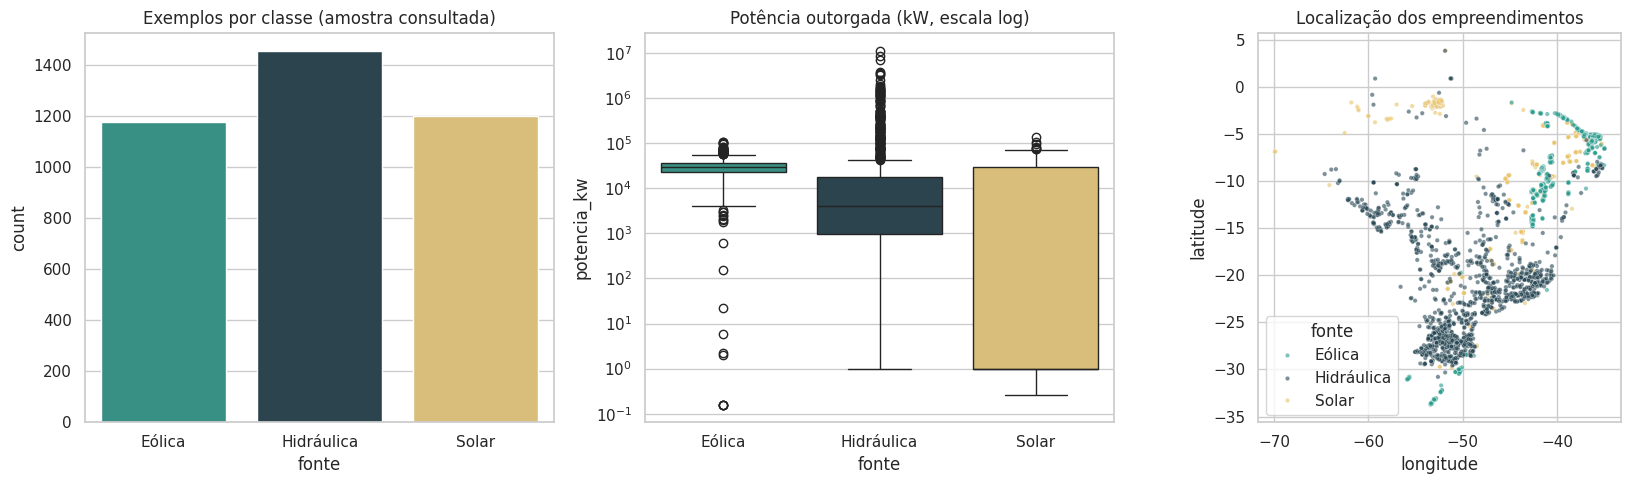

In [10]:
fig, eixos = plt.subplots(1, 3, figsize=(17, 5))
ordem = ["Eólica", "Hidráulica", "Solar"]
cores = {"Eólica": "#2a9d8f", "Hidráulica": "#264653", "Solar": "#e9c46a"}

sns.countplot(data=aneel_limpo, x="fonte", order=ordem, palette=cores, hue="fonte", legend=False, ax=eixos[0])
eixos[0].set_title("Exemplos por classe (amostra consultada)")

sns.boxplot(data=aneel_limpo, x="fonte", y="potencia_kw", order=ordem, palette=cores, hue="fonte", legend=False, ax=eixos[1])
eixos[1].set_yscale("log"); eixos[1].set_title("Potência outorgada (kW, escala log)")

sns.scatterplot(data=aneel_limpo, x="longitude", y="latitude", hue="fonte", hue_order=ordem,
                palette=cores, s=10, alpha=0.6, ax=eixos[2])
eixos[2].set_title("Localização dos empreendimentos"); eixos[2].set_aspect("equal")
plt.tight_layout(); plt.savefig(PASTA_FIG / "classificacao_exploracao.png", dpi=120); plt.show()

**Leitura dos gráficos:**

- **Eólica** concentra-se no litoral e no interior do **Nordeste** e no **Rio Grande do Sul**, com potências típicas entre ~20 e 40 MW (distribuição estreita).
- **Hidráulica** espalha-se pelo Sul, Sudeste e Centro-Oeste (bacias do Paraná, Uruguai, São Francisco) e cobre **toda** a faixa de potências — de CGHs com poucos kW a grandes UHEs.
- **Solar** tem duas populações: **micro/minigeração** (potências de ~1 kW, muitas vezes em áreas urbanas do Sudeste) e **usinas centralizadas** de dezenas de MW no Nordeste e em Minas Gerais — onde se sobrepõem às eólicas.

Essas sobreposições já indicam quais classes serão mais confundidas.

## 1.2 Definição de `X` e `y` e divisão estratificada

- `X` = `potencia_kw`, `latitude`, `longitude` (três entradas numéricas).
- `y` = `fonte` (Solar, Eólica, Hidráulica).
- Divisão **80% treino / 20% teste, estratificada por `fonte`**, semente 42. Nenhuma coluna que revele a resposta (sigla, CEG, nome) está no CSV.

In [11]:
X_c = aneel_limpo[["potencia_kw", "latitude", "longitude"]]
y_c = aneel_limpo["fonte"]
X_c_treino, X_c_teste, y_c_treino, y_c_teste = train_test_split(
    X_c, y_c, test_size=0.20, stratify=y_c, random_state=SEMENTE)

print("Treino:", X_c_treino.shape, " Teste:", X_c_teste.shape)
display(pd.DataFrame({"treino": y_c_treino.value_counts(normalize=True).round(3),
                      "teste": y_c_teste.value_counts(normalize=True).round(3)}))

Treino: (3063, 3)  Teste: (766, 3)


,treino,teste
fonte,,
Hidráulica,0.379,0.380
Solar,0.313,0.313
Eólica,0.307,0.307


## 1.3 Três classificadores

| Modelo | Por que foi escolhido | Pré-processamento (ajustado **só no treino**, dentro do `Pipeline`) |
|---|---|---|
| **Regressão Logística** | Modelo linear, interpretável; serve de **linha de base**. Fronteiras lineares testam se a separação é simples. | `log1p` na potência + `StandardScaler` |
| **kNN (k = 15)** | Classifica pela vizinhança: faz sentido porque empreendimentos da mesma fonte se agrupam geograficamente. k = 15 suaviza ruído. | `log1p` na potência + `StandardScaler` (distância é sensível à escala) |
| **Random Forest (300 árvores)** | Conjunto de árvores: captura regras não lineares do tipo "potência entre X e Y **e** latitude acima de Z", sem precisar de escala. | Nenhum (árvores são invariantes à escala) |

O `Pipeline` garante que o `StandardScaler` aprende média e desvio **apenas com o treino** e aplica os mesmos valores no teste. `log1p` é uma transformação fixa (não aprende nada dos dados).

In [12]:
log_potencia = FunctionTransformer(
    lambda X: np.column_stack([np.log1p(X[:, 0]), X[:, 1:]]), validate=True)

classificadores = {
    "Regressão Logística": make_pipeline(log_potencia, StandardScaler(),
                                         LogisticRegression(max_iter=2000, random_state=SEMENTE)),
    "kNN (k=15)": make_pipeline(log_potencia, StandardScaler(),
                                KNeighborsClassifier(n_neighbors=15)),
    "Random Forest": RandomForestClassifier(n_estimators=300, min_samples_leaf=2,
                                            random_state=SEMENTE, n_jobs=-1),
}

resultados_c, previsoes_c = [], {}
for nome, modelo in classificadores.items():
    modelo.fit(X_c_treino, y_c_treino)
    pred = modelo.predict(X_c_teste)
    previsoes_c[nome] = pred
    resultados_c.append({
        "Modelo": nome,
        "Accuracy": accuracy_score(y_c_teste, pred),
        "Precision (macro)": precision_score(y_c_teste, pred, average="macro"),
        "Recall (macro)": recall_score(y_c_teste, pred, average="macro"),
        "F1 (macro)": f1_score(y_c_teste, pred, average="macro"),
        "F1 (weighted)": f1_score(y_c_teste, pred, average="weighted"),
    })

tabela_c = pd.DataFrame(resultados_c).set_index("Modelo").round(3)
tabela_c

,Accuracy,Precision (macro),Recall (macro),F1 (macro),F1 (weighted)
Modelo,,,,,
Regressão Logística,0.832,0.847,0.828,0.825,0.830
kNN (k=15),0.950,0.951,0.950,0.950,0.950
Random Forest,0.974,0.975,0.973,0.974,0.974


**Tipo de média:** usamos **`macro`** como métrica principal — calcula Precision/Recall/F1 de cada classe e tira a média simples, dando o **mesmo peso** às três fontes, independentemente de quantos exemplos cada uma tem. O F1 `weighted` (ponderado pelo suporte) aparece só como referência; os dois ficam próximos porque o desbalanceamento é pequeno.

**Configuração idêntica para os três:** mesma divisão estratificada 80/20, mesma semente, mesmas três entradas, avaliação no mesmo conjunto de teste (766 empreendimentos).

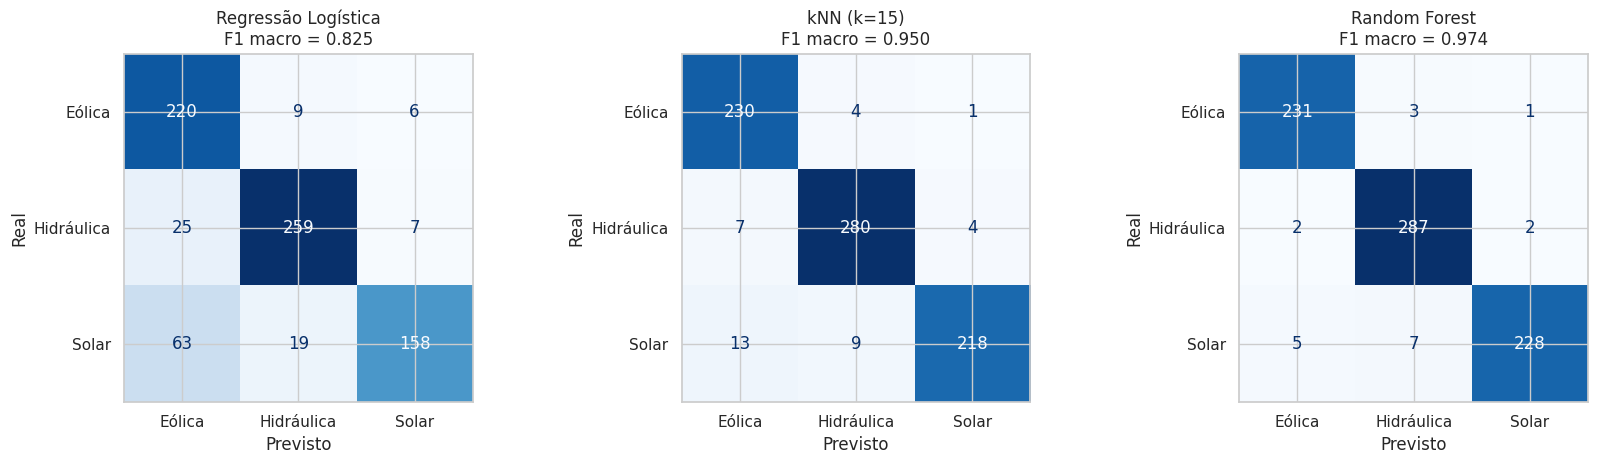

In [13]:
fig, eixos = plt.subplots(1, 3, figsize=(17, 4.8))
for eixo, (nome, pred) in zip(eixos, previsoes_c.items()):
    ConfusionMatrixDisplay.from_predictions(y_c_teste, pred, labels=ordem, cmap="Blues",
                                            colorbar=False, ax=eixo)
    eixo.set_title(f"{nome}\nF1 macro = {tabela_c.loc[nome, 'F1 (macro)']:.3f}")
    eixo.set_xlabel("Previsto"); eixo.set_ylabel("Real")
plt.tight_layout(); plt.savefig(PASTA_FIG / "classificacao_matrizes_confusao.png", dpi=120); plt.show()

In [14]:
melhor_c = tabela_c["F1 (macro)"].idxmax()
print(f"Relatório por classe — {melhor_c}\n")
print(classification_report(y_c_teste, previsoes_c[melhor_c], digits=3))

Relatório por classe — Random Forest

              precision    recall  f1-score   support

      Eólica      0.971     0.983     0.977       235
  Hidráulica      0.966     0.986     0.976       291
       Solar      0.987     0.950     0.968       240

    accuracy                          0.974       766
   macro avg      0.975     0.973     0.974       766
weighted avg      0.974     0.974     0.974       766



### Verificação de robustez (validação cruzada só no treino)

Uma única divisão pode favorecer um modelo por acaso. Rodamos validação cruzada estratificada de 5 dobras **dentro do conjunto de treino** (o teste continua intocado) para ver se a ordem dos modelos se mantém.

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMENTE)
linhas_cv = []
for nome, modelo in classificadores.items():
    r = cross_validate(modelo, X_c_treino, y_c_treino, cv=cv, scoring=["accuracy", "f1_macro"])
    linhas_cv.append({"Modelo": nome,
                      "Accuracy CV (média ± dp)": f"{r['test_accuracy'].mean():.3f} ± {r['test_accuracy'].std():.3f}",
                      "F1 macro CV (média ± dp)": f"{r['test_f1_macro'].mean():.3f} ± {r['test_f1_macro'].std():.3f}"})
pd.DataFrame(linhas_cv).set_index("Modelo")

,Accuracy CV (média ± dp),F1 macro CV (média ± dp)
Modelo,,
Regressão Logística,0.806 ± 0.013,0.800 ± 0.013
kNN (k=15),0.938 ± 0.011,0.936 ± 0.011
Random Forest,0.968 ± 0.005,0.968 ± 0.005


### Robustez espacial: e em regiões que o modelo nunca viu?

Parques eólicos e solares costumam ser cadastrados **em complexos**: várias usinas vizinhas, com potências e coordenadas quase iguais. Numa divisão aleatória, "irmãs" de uma mesma usina caem no treino e no teste, e o modelo pode acertar por **memorizar o local** em vez de aprender um padrão geral. Para medir isso, agrupamos os empreendimentos em células de 0,5° × 0,5° (≈ 55 km) e usamos `StratifiedGroupKFold`: cada célula fica inteira no treino **ou** na validação.

In [16]:
from sklearn.model_selection import StratifiedGroupKFold
celulas = (np.floor(X_c["latitude"] / 0.5).astype(int).astype(str) + "_" +
           np.floor(X_c["longitude"] / 0.5).astype(int).astype(str))
cv_espacial = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEMENTE)
linhas_esp = []
for nome, modelo in classificadores.items():
    r = cross_validate(modelo, X_c, y_c, groups=celulas, cv=cv_espacial, scoring="f1_macro")
    linhas_esp.append({"Modelo": nome, "F1 macro — divisão aleatória (teste)": tabela_c.loc[nome, "F1 (macro)"],
                       "F1 macro — regiões inéditas (CV espacial)": round(r["test_score"].mean(), 3)})
pd.DataFrame(linhas_esp).set_index("Modelo")

,F1 macro — divisão aleatória (teste),F1 macro — regiões inéditas (CV espacial)
Modelo,,
Regressão Logística,0.825,0.807
kNN (k=15),0.950,0.881
Random Forest,0.974,0.893


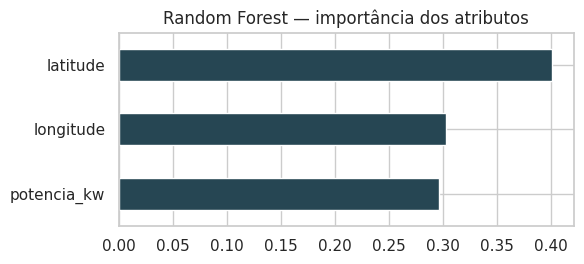

In [17]:
rf_c = classificadores["Random Forest"]
importancias_c = pd.Series(rf_c.feature_importances_, index=X_c.columns).sort_values()
importancias_c.plot.barh(figsize=(6, 2.8), color="#264653", title="Random Forest — importância dos atributos")
plt.tight_layout(); plt.savefig(PASTA_FIG / "classificacao_importancias.png", dpi=120); plt.show()

## 1.4 Interpretação — classificação

**Qual modelo escolher?** A **Random Forest** teve o melhor desempenho em todas as métricas (Accuracy 0,974; F1 macro 0,974), seguida do kNN (0,950) e, bem atrás, da Regressão Logística (0,825). A ordem se repete na validação cruzada do treino, com desvio-padrão pequeno, então não é sorte da divisão. Eu escolheria a Random Forest.

**Por que a Regressão Logística perde?** Ela traça fronteiras **lineares** no espaço (log potência, latitude, longitude). Mas as classes formam "manchas" geográficas e faixas de potência que se intercalam — por exemplo, Solar aparece tanto com ~1 kW no Sudeste quanto com ~30 MW no Nordeste. Uma reta não separa isso. Sua maior falha: **63 usinas solares classificadas como eólicas**.

**Classes mais confundidas (Random Forest):**

- **Solar → Eólica / Hidráulica** é o erro mais comum (Solar tem o menor recall, 0,95). As **usinas solares centralizadas do Nordeste** (RN, PB, PE, PI) têm potência de ~26–34 MW e ficam nas mesmas regiões dos parques eólicos, também com ~30 MW — potência e localização praticamente iguais. Já **solares pequenas em Minas Gerais e Rio de Janeiro** caem entre CGHs/PCHs de porte parecido.
- **Eólica ↔ Hidráulica** acontece no Sul (SC, RS, PR), onde as duas fontes coexistem com potências de alguns MW.
- Eólica é a classe mais fácil: potência numa faixa estreita e forte concentração no litoral nordestino e no RS.

**Limitações de prever a fonte só com potência e localização:**

1. **O resultado de ~97% é otimista.** Na validação espacial (regiões inteiras escondidas do treino), o F1 da Random Forest cai para cerca de 0,89 e o da Regressão Logística fica estável — sinal de que parte do acerto dos modelos flexíveis vem de **reconhecer complexos de usinas vizinhas** já vistos no treino, não de uma regra física geral.
2. **Potência e posição não descrevem a física da fonte.** O que realmente define onde há usina eólica, solar ou hidráulica é vento médio, irradiação, relevo e presença de rios. Duas usinas no mesmo município e com a mesma potência podem ser de fontes diferentes, e nenhum modelo com essas três entradas consegue distinguir.
3. **Amostra não representativa.** Foram no máximo 1200 registros por sigla, na ordem devolvida pela API — isso não é uma amostra aleatória do cadastro e **não reflete a participação das fontes na matriz energética brasileira**. O cadastro também mistura empreendimentos em operação, construção e outorga.
4. **Qualidade dos dados:** 47 coordenadas inválidas foram removidas; as coordenadas restantes são aproximadas.
5. Numa aplicação real, a fonte já consta no cadastro da ANEEL; o valor prático desse classificador seria, no máximo, **detectar inconsistências** (usinas cuja fonte declarada destoa do padrão da região), sempre com verificação humana.

# Tarefa 2 — Regressão (Open-Meteo)

**Pergunta:** dadas as condições meteorológicas e a hora local em Petrolina (PE), qual é a radiação solar horizontal média naquela hora? A resposta é um **número**, então o problema é de regressão.

A API histórica do [Open-Meteo](https://open-meteo.com/en/docs/historical-weather-api) devolve dados horários para coordenadas e período escolhidos. Usamos **1º de abril a 30 de junho de 2025**, em horário local. São dados históricos estimados por modelos/reanálise, não leituras de um sensor particular. **Radiação em W/m² não equivale à energia em kWh nem à geração de um painel.**

### Parâmetros da requisição

| Parâmetro | Valor nesta avaliação | Significado |
|---|---|---|
| `latitude`, `longitude` | `-9.39`, `-40.50` | Coordenadas aproximadas de Petrolina (PE) |
| `start_date`, `end_date` | `2025-04-01`, `2025-06-30` | Período histórico consultado, inclusive as datas extremas |
| `timezone` | `America/Recife` | Faz `time` representar a hora local |
| `hourly` | Lista das cinco variáveis abaixo | Solicita valores horários em JSON |

### Atributos do conjunto de dados

| Campo da API → CSV | Significado e unidade | Uso na tarefa |
|---|---|---|
| `time` → `data_hora` | Data e hora local de cada registro | Ordenar e separar por tempo; não é entrada em X |
| `temperature_2m` → `temperatura_c` | Temperatura do ar a 2 m, em °C | Entrada |
| `relative_humidity_2m` → `umidade_pct` | Umidade relativa a 2 m, em % | Entrada |
| `cloud_cover` → `nuvens_pct` | Cobertura total de nuvens, em % | Entrada |
| `wind_speed_10m` → `vento_kmh` | Velocidade do vento a 10 m, em km/h | Entrada |
| `time` → `hora` | Hora local extraída da data, de 7 a 17 nesta amostra | Entrada |
| `shortwave_radiation` → `radiacao_w_m2` | Radiação solar global horizontal média da hora anterior, em W/m² | Alvo numérico `y`; **não entra em X** |

A resposta inclui `hourly` (listas dos valores, alinhadas por índice), `hourly_units` (unidades) e metadados da localização. Cada linha do CSV final representa **uma hora entre 7h e 17h**; esse recorte reduz o domínio de horas noturnas, mas não remove a importância da hora para a previsão.

### 3. Consultar o histórico meteorológico

A chamada usa GET, sem cadastro ou chave para esta consulta pública de uso educacional. Se `hourly` faltar, verifique datas e parâmetros.

In [18]:
URL_METEO = "https://archive-api.open-meteo.com/v1/archive"
parametros_meteo = {
    "latitude": -9.39,
    "longitude": -40.50,
    "start_date": "2025-04-01",
    "end_date": "2025-06-30",
    "timezone": "America/Recife",
    "hourly": ",".join(["temperature_2m", "relative_humidity_2m",
                         "cloud_cover", "wind_speed_10m", "shortwave_radiation"]),
}
print("Open-Meteo: consulta pública, sem token")

Open-Meteo: consulta pública, sem token


In [19]:
ARQ_METEO = Path("meteo_regressao_orange.csv")
consultar_meteo = ATUALIZAR_DADOS or not ARQ_METEO.exists()

if consultar_meteo:
    resposta_meteo = consultar_api(URL_METEO, parametros_meteo)
    if "hourly" not in resposta_meteo:
        raise ValueError("Resposta sem a seção hourly")
    horas_api = resposta_meteo["hourly"]
    print("Campos recebidos:", list(horas_api))
    print("Unidades informadas pela API:", resposta_meteo.get("hourly_units", {}))
    print("Quantidade de horários:", len(horas_api["time"]))
else:
    print(f"Usando o arquivo versionado {ARQ_METEO} (ATUALIZAR_DADOS = False)")

Usando o arquivo versionado meteo_regressao_orange.csv (ATUALIZAR_DADOS = False)


### 4. Gerar o CSV horário

As listas de `hourly` são alinhadas: o índice 0 de cada variável se refere ao índice 0 de `time`. Percorremos esses índices, mantemos as horas de 7h a 17h e descartamos linhas com valores ausentes. A data permanece ordenada para facilitar uma avaliação temporal.

In [20]:
if consultar_meteo:
    nomes_api = ["temperature_2m", "relative_humidity_2m", "cloud_cover",
                 "wind_speed_10m", "shortwave_radiation"]
    linhas_regressao = []
    for indice, data_hora in enumerate(horas_api["time"]):
        hora = int(data_hora[11:13])
        valores = [horas_api[nome][indice] for nome in nomes_api]
        if 7 <= hora <= 17 and all(valor is not None for valor in valores):
            linhas_regressao.append([data_hora, *valores[:4], hora, valores[4]])
    if len(linhas_regressao) < 100:
        raise ValueError("Poucos horários válidos: confira a resposta do Open-Meteo")
    print("Horas válidas:", len(linhas_regressao))
    print("Primeiro exemplo:", linhas_regressao[0])

In [21]:
if consultar_meteo:
    with open("meteo_regressao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
        escritor = csv.writer(arquivo)
        escritor.writerow(["data_hora", "temperatura_c", "umidade_pct",
                           "nuvens_pct", "vento_kmh", "hora", "radiacao_w_m2"])
        escritor.writerows(linhas_regressao)
    print("Salvo: meteo_regressao_orange.csv")

### O que você deve fazer — regressão

1. Carregue o CSV, explique as colunas, examine valores ausentes e apresente ao menos uma visualização. Defina `X` (cinco entradas) e `y` (`radiacao_w_m2`).
2. Mantenha as linhas em ordem de `data_hora`: use aproximadamente **80% das primeiras horas para treino** e as 20% finais para teste. Evite embaralhar as horas. Ajuste transformações apenas com o treino.
3. Escolha, justifique e treine **três algoritmos de regressão diferentes** com a mesma divisão. Os imports e a implementação são sua responsabilidade.
4. Compare **MAE** (W/m²), **MSE** ((W/m²)²) e **R²**; faça um gráfico de valores reais × previstos de pelo menos um modelo.
5. Interprete os erros, discuta o peso da hora e explique por que essa estimativa da radiação **não prevê automaticamente a energia produzida** por um sistema fotovoltaico.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico e interpretação escrita. Nenhum valor de `radiacao_w_m2` deve ser usado para criar uma entrada do mesmo registro.

## 2.1 Exploração dos dados (regressão)

In [22]:
meteo = pd.read_csv("meteo_regressao_orange.csv", encoding="utf-8-sig", parse_dates=["data_hora"])
meteo = meteo.sort_values("data_hora").reset_index(drop=True)
print("Formato:", meteo.shape)
print("Período:", meteo["data_hora"].min(), "→", meteo["data_hora"].max())
print("Dias distintos:", meteo["data_hora"].dt.date.nunique(), "| horas por dia:", sorted(meteo["hora"].unique()))
print("\nValores ausentes:"); print(meteo.isna().sum())
meteo.describe()

Formato: (1001, 7)
Período: 2025-04-01 07:00:00 → 2025-06-30 17:00:00
Dias distintos: 91 | horas por dia: [np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17)]

Valores ausentes:
data_hora        0
temperatura_c    0
umidade_pct      0
nuvens_pct       0
vento_kmh        0
hora             0
radiacao_w_m2    0
dtype: int64


,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
count,1001,1001.000,1001.000,1001.000,1001.000,1001.000,1001.000
mean,2025-05-16 12:00:00,28.886,50.544,55.109,15.465,12.000,472.854
min,2025-04-01 07:00:00,19.500,21.000,0.000,2.300,7.000,13.000
25%,2025-04-23 15:00:00,26.300,38.000,19.000,12.200,9.000,250.000
50%,2025-05-16 12:00:00,29.100,49.000,54.000,15.400,12.000,466.000
75%,2025-06-08 09:00:00,31.700,61.000,98.000,19.000,15.000,696.000
max,2025-06-30 17:00:00,36.100,95.000,100.000,30.100,17.000,1002.000
std,NaN,3.657,15.914,37.851,4.924,3.164,256.369


| Coluna | Significado | Papel |
|---|---|---|
| `data_hora` | Data e hora local (America/Recife) | Só para ordenar e separar no tempo — **não entra em X** |
| `temperatura_c` | Temperatura do ar a 2 m (°C) | Entrada |
| `umidade_pct` | Umidade relativa a 2 m (%) | Entrada |
| `nuvens_pct` | Cobertura total de nuvens (%) | Entrada |
| `vento_kmh` | Vento a 10 m (km/h) | Entrada |
| `hora` | Hora local, 7 a 17 | Entrada |
| `radiacao_w_m2` | Radiação global horizontal média da hora anterior (W/m²) | Alvo `y` |

São 91 dias × 11 horas = 1001 linhas, sem ausentes.

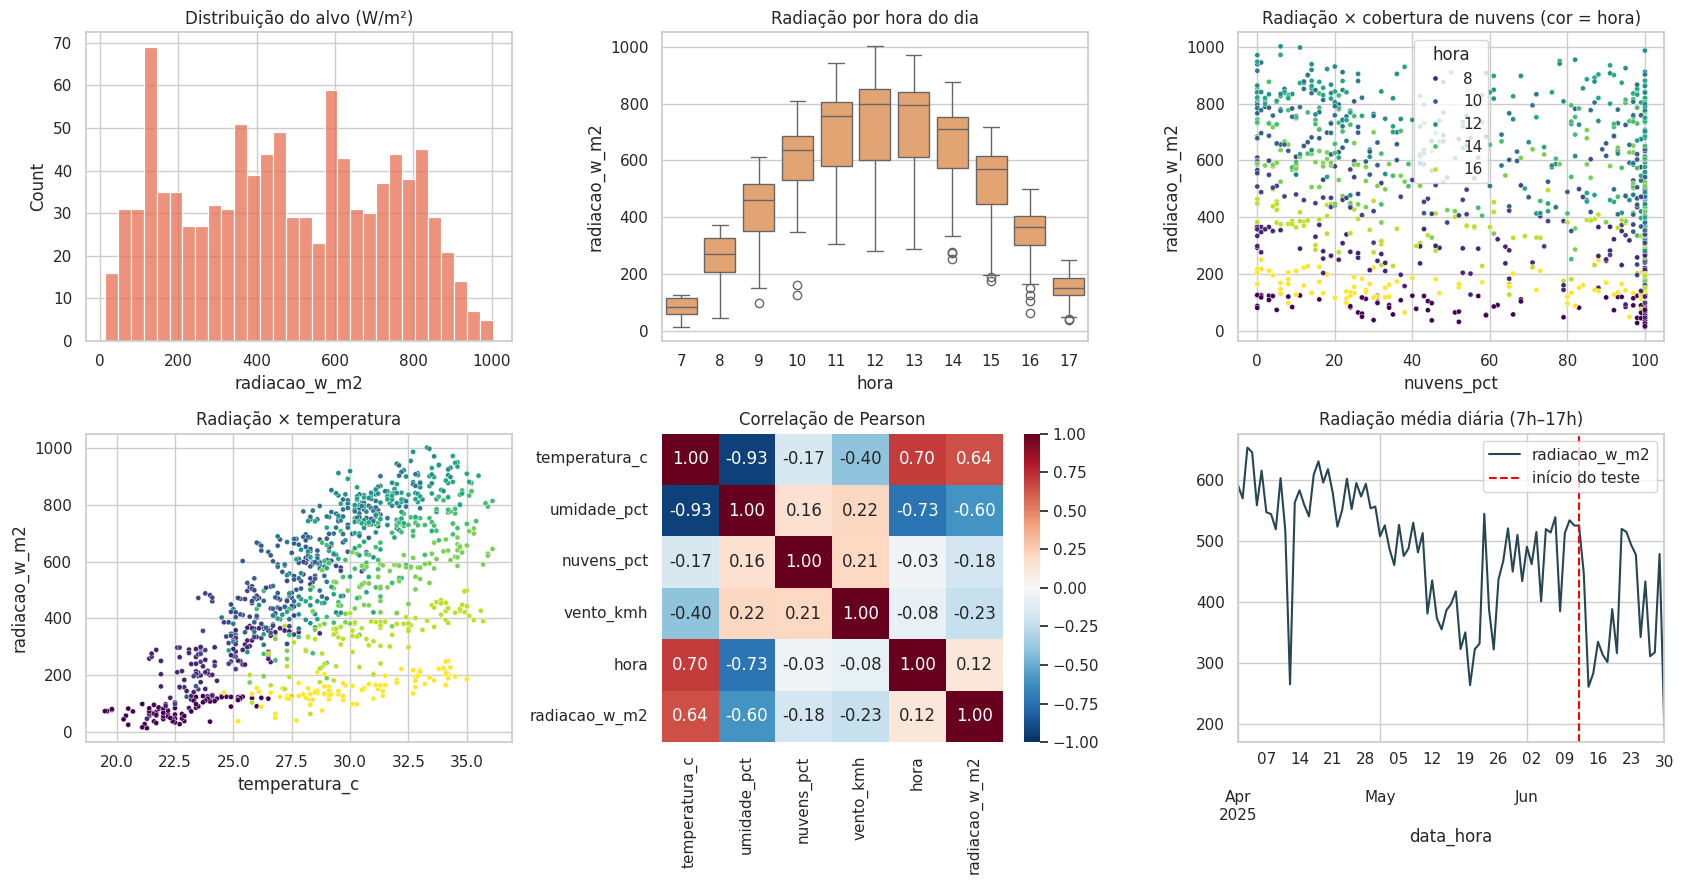

In [23]:
fig, eixos = plt.subplots(2, 3, figsize=(17, 9))
sns.histplot(meteo["radiacao_w_m2"], bins=30, color="#e76f51", ax=eixos[0, 0])
eixos[0, 0].set_title("Distribuição do alvo (W/m²)")

sns.boxplot(data=meteo, x="hora", y="radiacao_w_m2", color="#f4a261", ax=eixos[0, 1])
eixos[0, 1].set_title("Radiação por hora do dia")

sns.scatterplot(data=meteo, x="nuvens_pct", y="radiacao_w_m2", hue="hora", palette="viridis",
                s=14, ax=eixos[0, 2])
eixos[0, 2].set_title("Radiação × cobertura de nuvens (cor = hora)")

sns.scatterplot(data=meteo, x="temperatura_c", y="radiacao_w_m2", hue="hora", palette="viridis",
                s=14, legend=False, ax=eixos[1, 0])
eixos[1, 0].set_title("Radiação × temperatura")

sns.heatmap(meteo.drop(columns="data_hora").corr(), annot=True, fmt=".2f", cmap="RdBu_r",
            vmin=-1, vmax=1, ax=eixos[1, 1])
eixos[1, 1].set_title("Correlação de Pearson")

diaria = meteo.set_index("data_hora")["radiacao_w_m2"].resample("D").mean()
diaria.plot(ax=eixos[1, 2], color="#264653")
eixos[1, 2].axvline(meteo.loc[int(len(meteo) * 0.8), "data_hora"], color="red", ls="--", label="início do teste")
eixos[1, 2].set_title("Radiação média diária (7h–17h)"); eixos[1, 2].legend()
plt.tight_layout(); plt.savefig(PASTA_FIG / "regressao_exploracao.png", dpi=120); plt.show()

**Leitura dos gráficos:**

- **A hora é o principal determinante**, mas numa forma de **sino** (máximo entre 12h e 13h, mínimos às 7h e 17h). Por isso a correlação linear de `hora` com o alvo é quase nula (~0,12): Pearson mede apenas relação **linear** e não enxerga o formato em ∩.
- **Temperatura** (+0,64) e **umidade** (−0,60) se correlacionam com a radiação em parte porque **também seguem o ciclo do dia** (o sol aquece o ar e reduz a umidade relativa). Não são causas independentes da radiação.
- **Nuvens** reduzem a radiação, mas o efeito depende da hora (às 7h a radiação é baixa com ou sem nuvens).
- A série diária mostra **queda de abril para junho**: o período de teste (fim de junho) está perto do solstício de inverno, com sol mais baixo — uma **mudança de distribuição** que os modelos precisarão enfrentar.

## 2.2 `X`, `y` e divisão temporal

- `X` = `temperatura_c`, `umidade_pct`, `nuvens_pct`, `vento_kmh`, `hora` (cinco entradas).
- `y` = `radiacao_w_m2`. Nenhuma transformação de `radiacao_w_m2` entra em `X`.
- As linhas estão em ordem cronológica: **as primeiras 80% (801 horas) são treino e as 20% finais (200 horas) são teste**, sem embaralhar. Assim o modelo é avaliado em dias **futuros** em relação ao treino, como aconteceria na prática.

In [24]:
entradas_r = ["temperatura_c", "umidade_pct", "nuvens_pct", "vento_kmh", "hora"]
corte = int(round(len(meteo) * 0.80))
treino_r, teste_r = meteo.iloc[:corte], meteo.iloc[corte:]
X_r_treino, y_r_treino = treino_r[entradas_r], treino_r["radiacao_w_m2"]
X_r_teste, y_r_teste = teste_r[entradas_r], teste_r["radiacao_w_m2"]

print(f"Treino: {len(treino_r)} horas  ({treino_r['data_hora'].min()} → {treino_r['data_hora'].max()})")
print(f"Teste : {len(teste_r)} horas  ({teste_r['data_hora'].min()} → {teste_r['data_hora'].max()})")

Treino: 801 horas  (2025-04-01 07:00:00 → 2025-06-12 15:00:00)
Teste : 200 horas  (2025-06-12 16:00:00 → 2025-06-30 17:00:00)


## 2.3 Três regressores

| Modelo | Por que foi escolhido | Pré-processamento |
|---|---|---|
| **Regressão Linear** | Linha de base simples e interpretável. Assume relação linear — esperamos que sofra com a forma em sino da `hora`. | `StandardScaler` ajustado no treino (não altera as previsões da regressão linear, mas deixa os coeficientes comparáveis) |
| **Árvore de Decisão** (`max_depth=8`, `min_samples_leaf=5`) | Aprende regras não lineares ("se hora entre 10 e 14 **e** nuvens < 40%…"). Profundidade limitada para reduzir sobreajuste. | Nenhum |
| **Random Forest** (300 árvores, `min_samples_leaf=3`) | Média de muitas árvores treinadas em amostras diferentes: mantém a não linearidade e reduz a variância de uma árvore isolada. | Nenhum |

Como referência extra (não conta como um dos três modelos), calculamos uma **previsão ingênua**: a radiação média de cada hora no treino. Um modelo útil precisa superá-la.

In [25]:
regressores = {
    "Regressão Linear": make_pipeline(StandardScaler(), LinearRegression()),
    "Árvore de Decisão": DecisionTreeRegressor(max_depth=8, min_samples_leaf=5, random_state=SEMENTE),
    "Random Forest": RandomForestRegressor(n_estimators=300, min_samples_leaf=3,
                                           random_state=SEMENTE, n_jobs=-1),
}

def metricas_regressao(nome, real, previsto):
    return {"Modelo": nome,
            "MAE (W/m²)": mean_absolute_error(real, previsto),
            "MSE ((W/m²)²)": mean_squared_error(real, previsto),
            "RMSE (W/m²)": np.sqrt(mean_squared_error(real, previsto)),
            "R²": r2_score(real, previsto)}

resultados_r, previsoes_r = [], {}
for nome, modelo in regressores.items():
    modelo.fit(X_r_treino, y_r_treino)
    previsoes_r[nome] = modelo.predict(X_r_teste)
    resultados_r.append(metricas_regressao(nome, y_r_teste, previsoes_r[nome]))

media_por_hora = y_r_treino.groupby(X_r_treino["hora"]).mean()
ingenua = X_r_teste["hora"].map(media_por_hora)
resultados_r.append(metricas_regressao("Referência: média por hora (treino)", y_r_teste, ingenua))

tabela_r = pd.DataFrame(resultados_r).set_index("Modelo").round(3)
tabela_r

,MAE (W/m²),MSE ((W/m²)²),RMSE (W/m²),R²
Modelo,,,,
Regressão Linear,145.865,30176.551,173.714,0.357
Árvore de Decisão,84.884,13189.643,114.846,0.719
Random Forest,69.391,7904.247,88.906,0.832
Referência: média por hora (treino),132.608,33642.950,183.420,0.283


**Configuração idêntica para os três:** mesma divisão temporal (801 primeiras horas para treino, 200 últimas para teste), mesmas cinco entradas, mesma semente. MSE está em (W/m²)²; o RMSE (= √MSE) aparece para facilitar a leitura em W/m².

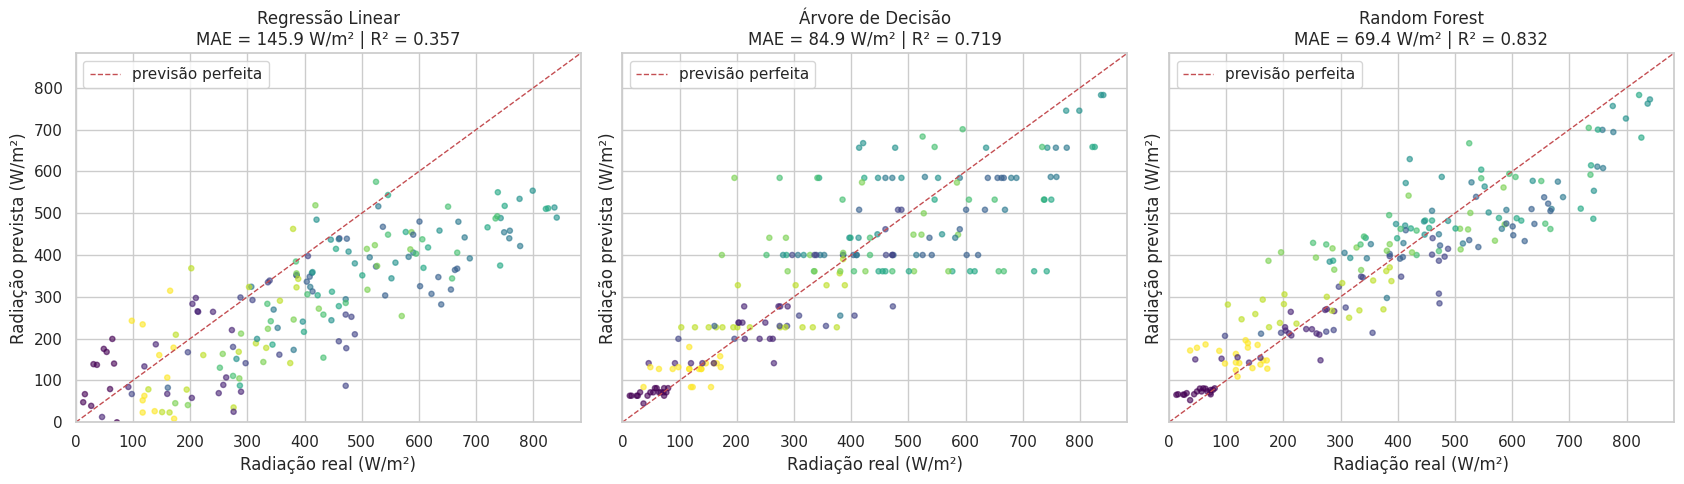

In [26]:
fig, eixos = plt.subplots(1, 3, figsize=(17, 5), sharex=True, sharey=True)
limite = [0, max(y_r_teste.max(), max(p.max() for p in previsoes_r.values())) * 1.05]
for eixo, (nome, pred) in zip(eixos, previsoes_r.items()):
    eixo.scatter(y_r_teste, pred, s=14, alpha=0.6, c=X_r_teste["hora"], cmap="viridis")
    eixo.plot(limite, limite, "r--", lw=1, label="previsão perfeita")
    eixo.set_title(f"{nome}\nMAE = {tabela_r.loc[nome, 'MAE (W/m²)']:.1f} W/m² | R² = {tabela_r.loc[nome, 'R²']:.3f}")
    eixo.set_xlabel("Radiação real (W/m²)"); eixo.set_ylabel("Radiação prevista (W/m²)")
    eixo.set_xlim(limite); eixo.set_ylim(limite); eixo.legend(loc="upper left")
plt.tight_layout(); plt.savefig(PASTA_FIG / "regressao_real_vs_previsto.png", dpi=120); plt.show()

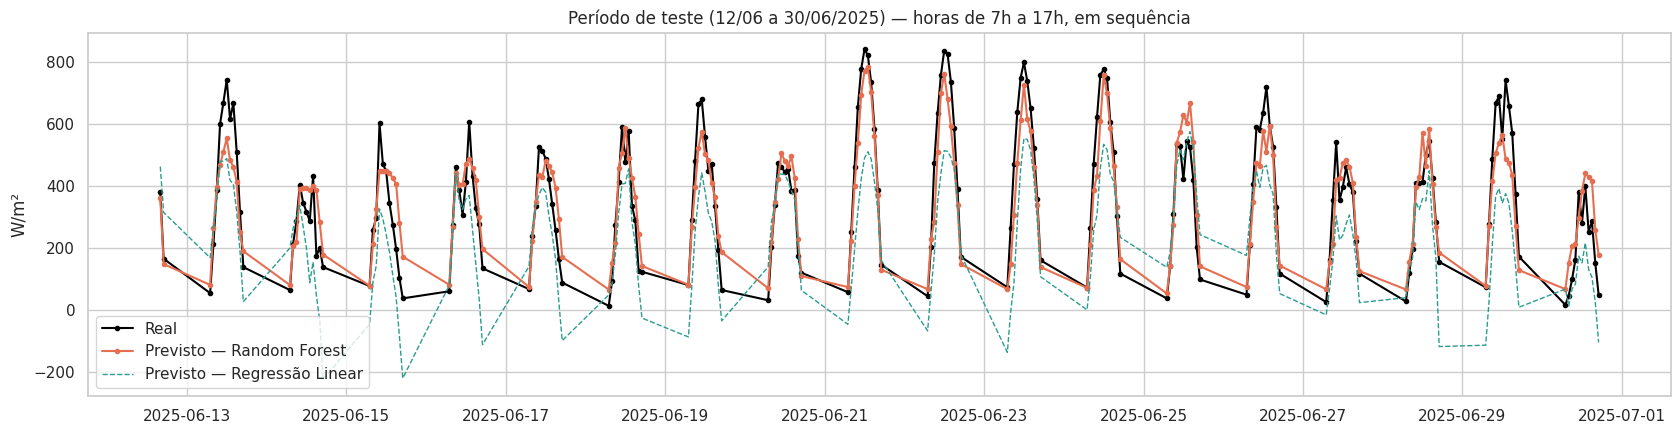

In [27]:
melhor_r = tabela_r.drop(index="Referência: média por hora (treino)")["R²"].idxmax()
fig, eixo = plt.subplots(figsize=(17, 4.5))
eixo.plot(teste_r["data_hora"].values, y_r_teste.values, "o-", ms=3, color="black", label="Real")
eixo.plot(teste_r["data_hora"].values, previsoes_r[melhor_r], "o-", ms=3, color="#e76f51", label=f"Previsto — {melhor_r}")
eixo.plot(teste_r["data_hora"].values, previsoes_r["Regressão Linear"], "--", lw=1, color="#2a9d8f", label="Previsto — Regressão Linear")
eixo.set_ylabel("W/m²"); eixo.set_title("Período de teste (12/06 a 30/06/2025) — horas de 7h a 17h, em sequência")
eixo.legend(); plt.tight_layout(); plt.savefig(PASTA_FIG / "regressao_serie_teste.png", dpi=120); plt.show()

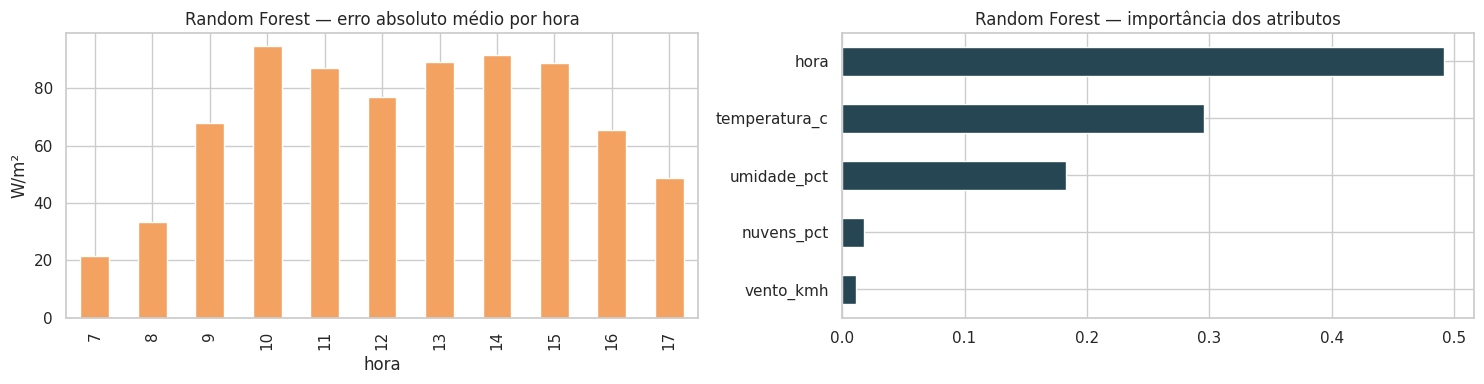

,coef. padronizado (W/m² por 1 dp)
temperatura_c,348.5
umidade_pct,21.9
nuvens_pct,-9.7
vento_kmh,46.7
hora,-201.4


In [28]:
erros = teste_r.assign(erro_abs=np.abs(y_r_teste.values - previsoes_r[melhor_r]))
fig, eixos = plt.subplots(1, 2, figsize=(15, 4))
erros.groupby("hora")["erro_abs"].mean().plot.bar(ax=eixos[0], color="#f4a261",
                                                  title=f"{melhor_r} — erro absoluto médio por hora")
eixos[0].set_ylabel("W/m²")
rf_r = regressores["Random Forest"]
pd.Series(rf_r.feature_importances_, index=entradas_r).sort_values().plot.barh(
    ax=eixos[1], color="#264653", title="Random Forest — importância dos atributos")
plt.tight_layout(); plt.savefig(PASTA_FIG / "regressao_erros_importancias.png", dpi=120); plt.show()

coef = regressores["Regressão Linear"][-1].coef_
display(pd.Series(coef, index=entradas_r, name="coef. padronizado (W/m² por 1 dp)").round(1).to_frame())

## 2.4 Interpretação — regressão

**Resultado:** a **Random Forest** foi a melhor (MAE ≈ 69 W/m², R² ≈ 0,83), seguida da Árvore de Decisão (MAE ≈ 85 W/m², R² ≈ 0,72). A **Regressão Linear** ficou muito atrás (MAE ≈ 146 W/m², R² ≈ 0,36) — pouco melhor que a previsão ingênua "média de cada hora" (R² ≈ 0,28) e pior que ela em MAE.

**O papel da hora.** A hora é o atributo mais importante da Random Forest (~49% da importância), mas tem correlação linear quase nula com o alvo. Isso acontece porque a radiação segue um **sino** ao longo do dia: sobe depois do nascer do sol, atinge o máximo entre 12h e 13h e cai até o fim da tarde. As 7h e as 17h têm radiação baixa **pelo mesmo motivo** (sol perto do horizonte), embora estejam em extremos opostos da escala numérica. A Regressão Linear só consegue dizer "mais hora = mais (ou menos) radiação", por isso chega a um coeficiente negativo para `hora` e usa a **temperatura** como substituta do ciclo solar. As árvores dividem a hora em faixas (manhã, meio-dia, tarde) e combinam cada faixa com nuvens e umidade — exatamente a estrutura do problema. (Uma melhoria possível seria transformar a hora em seno/cosseno ou no ângulo de elevação solar.)

**Erros e mudança de distribuição.** O teste cobre de 12 a 30 de junho, perto do **solstício de inverno**, quando o sol fica mais baixo e a radiação média cai (média de ~498 W/m² no treino contra ~372 W/m² no teste). Os modelos só viram abril–junho, com sol mais alto:

- A Regressão Linear **subestima sistematicamente** (em média prevê ~125 W/m² abaixo do real): ela usa a temperatura como principal substituta do sol (coeficiente padronizado ≈ +350 W/m²) e, no fim de junho, as manhãs e tardes ficam mais frias sem que a radiação caia na mesma proporção. Ela também prevê valores altos às 7h e baixos no pico, porque não representa o sino da hora.
- A Random Forest tem viés médio pequeno (subestima ~7 W/m² em média). Seus maiores erros ocorrem **entre 10h e 15h**, justamente quando a radiação é alta e uma nuvem passageira pode derrubá-la em centenas de W/m² dentro da hora — algo que a cobertura de nuvens horária não captura por completo.
- Uma limitação estrutural das árvores: **não extrapolam** além dos valores vistos no treino. Com um ano inteiro de dados, o modelo cobriria as quatro estações.

**Por que radiação não é geração elétrica.** `radiacao_w_m2` é uma **potência por área** (W/m²) que chega a uma superfície **horizontal**, estimada por modelo/reanálise para um ponto — não é energia (kWh) nem medição de um sistema. Para chegar à energia produzida seria preciso considerar: a **área** e a **eficiência** dos módulos (tipicamente 18–22%); a **inclinação e orientação** dos painéis (a radiação no plano inclinado difere da horizontal) e se há rastreador; a **temperatura das células** (a eficiência cai com o calor — em Petrolina, cerca de −0,3% a −0,4% por °C acima de 25 °C); perdas em **inversor**, cabos, sujeira e sombreamento; a **potência nominal** e a limitação (*clipping*) do inversor; e disponibilidade/curtailment da rede. Além disso, energia = potência × tempo: seria preciso integrar ao longo das horas. Estimar bem a radiação é o primeiro passo de uma previsão de geração, mas não a substitui.

# Conclusões

**Classificação (ANEEL).** Com apenas potência, latitude e longitude, a Random Forest atingiu Accuracy e F1 macro de 0,974 no teste estratificado, contra 0,950 do kNN e 0,825 da Regressão Logística. A principal confusão é entre solares centralizadas e parques eólicos do Nordeste, que têm porte e localização semelhantes. A validação espacial (F1 ≈ 0,89 em regiões inéditas) mostra que parte do acerto vem de reconhecer complexos vizinhos; sem atributos físicos (vento, irradiação, relevo, hidrografia), o modelo não serve para decidir a fonte de um empreendimento novo, e a amostra não representa a matriz energética brasileira.

**Regressão (Open-Meteo).** Com divisão temporal 80/20, a Random Forest estimou a radiação com MAE ≈ 69 W/m² e R² ≈ 0,83, superando a Árvore de Decisão (R² ≈ 0,72) e, com folga, a Regressão Linear (R² ≈ 0,36). A hora do dia é o atributo mais importante, mas atua de forma não linear (sino), o que explica o fraco desempenho do modelo linear. O teste no fim de junho, perto do solstício, expõe a mudança sazonal. Radiação horizontal em W/m² é insumo, não resultado: converter em energia exige área, eficiência, inclinação, temperatura das células e perdas do sistema.

# Entrega pelo GitHub

Envie **apenas o link do repositório público**. Organize-o com:

- `README.md` contendo objetivo, fontes e período dos dados, instruções para executar o notebook e resumo dos resultados;
- notebook `.ipynb` com a consulta às APIs, sua análise, os **três classificadores e os três regressores**, todos os imports necessários adicionados por você e conclusões em Markdown;
- os dois CSVs gerados (ou instruções completas e testadas para reproduzi-los) e eventuais figuras utilizadas.

Verifique se o notebook roda **na ordem das células** a partir de um ambiente limpo. Não inclua senhas, tokens ou arquivos sem relação com a avaliação. A banca deve conseguir encontrar as seis comparações e as respostas às duas tarefas sem procurar uma agulha no palheiro.

### Fontes

- [ANEEL — SIGA](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel)
- [ANEEL — recurso e campos usados](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel/resource/11ec447d-698d-4ab8-977f-b424d5deee6a)
- [Open-Meteo — histórico e unidades](https://open-meteo.com/en/docs/historical-weather-api)